In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from qiskit.qasm3 import dumps as qasm3_dumps


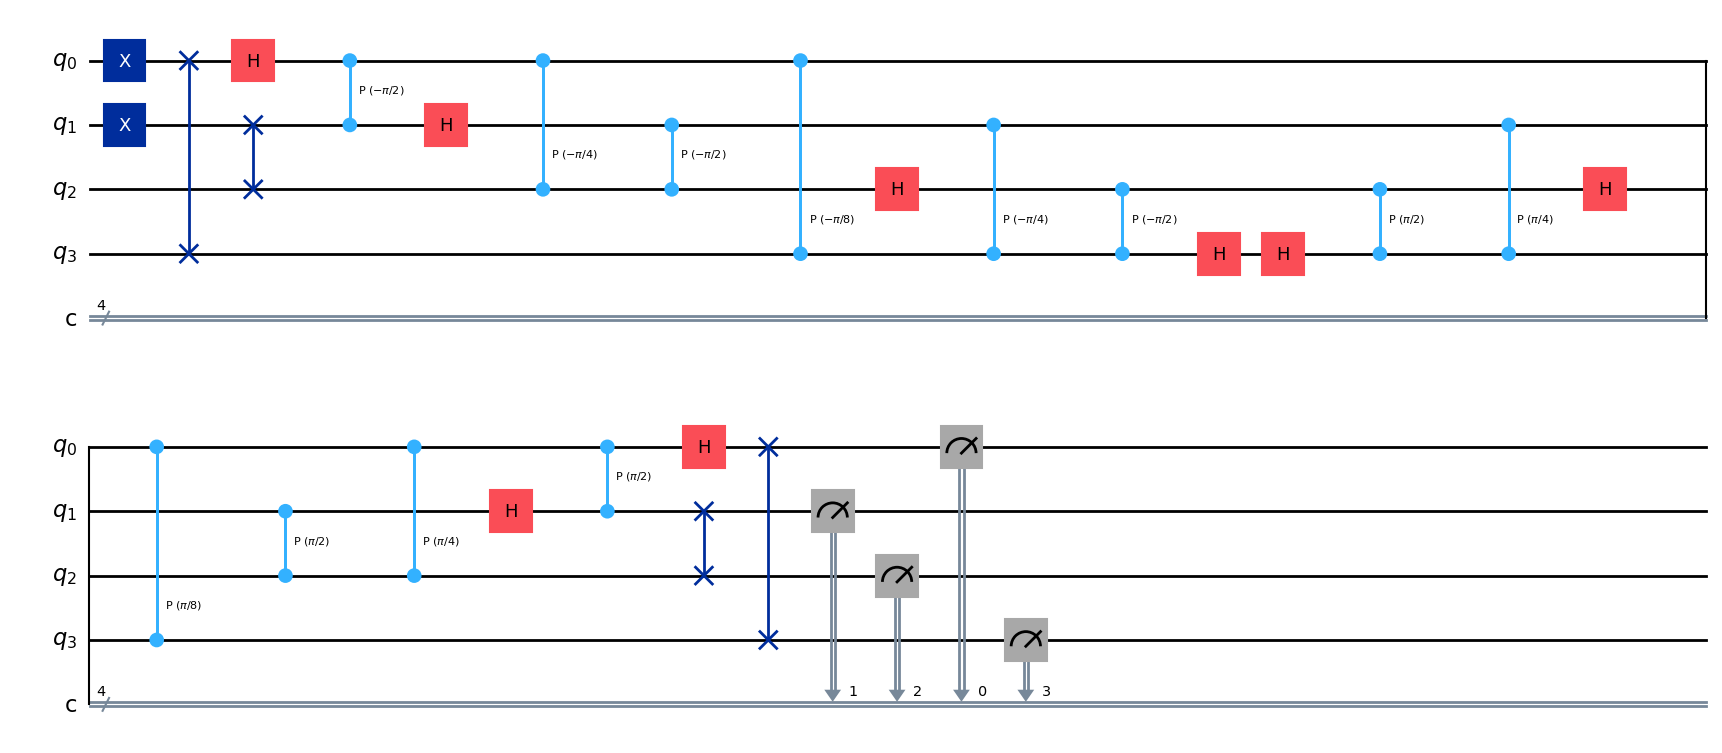

In [46]:
n = 4
qc = QuantumCircuit(n, n)
# qreg_q = QuantumRegister(3, 'q')
# creg_c = ClassicalRegister(3, 'c')
# circuit = QuantumCircuit(qreg_q, creg_c)

# Add in frequency of 3
qc.x(0)
qc.x(1)

# IQFT
for q in range(n//2):
    qc.swap(q, n - q - 1)

for target in range(n): # start, stop, step
    for control in range(target):
        r = target - control + 1
        qc.cp(-2 * pi / 2 ** r, control, target)

    qc.h(target)

# QFT
for target in range(n-1, -1, -1): # start, stop, step
    qc.h(target)

    for control in range(target-1, -1, -1):
        r = target - control + 1
        qc.cp(2 * pi / 2 ** r, control, target)

for q in range(n//2):
    qc.swap(q, n - q - 1)

qc.measure(range(n), range(n))

qc.draw(output="mpl")

In [47]:
print(qasm3_dumps(qc))

OPENQASM 3.0;
include "stdgates.inc";
bit[4] c;
qubit[4] q;
x q[0];
x q[1];
swap q[0], q[3];
swap q[1], q[2];
h q[0];
cp(-pi/2) q[0], q[1];
h q[1];
cp(-pi/4) q[0], q[2];
cp(-pi/2) q[1], q[2];
h q[2];
cp(-pi/8) q[0], q[3];
cp(-pi/4) q[1], q[3];
cp(-pi/2) q[2], q[3];
h q[3];
h q[3];
cp(pi/2) q[2], q[3];
cp(pi/4) q[1], q[3];
cp(pi/8) q[0], q[3];
h q[2];
cp(pi/2) q[1], q[2];
cp(pi/4) q[0], q[2];
h q[1];
cp(pi/2) q[0], q[1];
h q[0];
swap q[0], q[3];
swap q[1], q[2];
c[0] = measure q[0];
c[1] = measure q[1];
c[2] = measure q[2];
c[3] = measure q[3];



In [48]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2 as AerSampler

In [49]:
pass_manager = generate_preset_pass_manager(
    optimization_level=2, backend=AerSimulator())
isa_circuit = pass_manager.run(qc)
noise_model = NoiseModel()

sampler = AerSampler(options={"backend_options": {"noise_model": noise_model}})
job = sampler.run([isa_circuit], shots=1024)
result = job.result()[0]
print(result.data.c.get_counts())

{'0011': 1024}


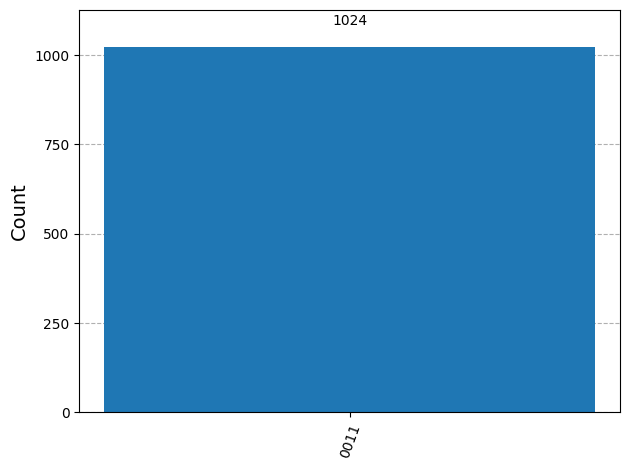

In [50]:
from qiskit.visualization import plot_histogram
plot_histogram(result.data.c.get_counts())

In [51]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

service = QiskitRuntimeService()

In [52]:
service.backends()

[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_torino')>,
 <IBMBackend('ibm_marrakesh')>]

In [53]:
backend = service.least_busy(operational=True, min_num_qubits=n)
print(backend)

<IBMBackend('ibm_fez')>


In [54]:
backend.configuration()

In [55]:

pass_manager = generate_preset_pass_manager(
    optimization_level=2, backend=backend)
isa_circuit = pass_manager.run(qc)
sampler = Sampler(backend)
job = sampler.run([isa_circuit])
result = job.result()

In [56]:
sampler_result = result[0]
counts = sampler_result.data.c.get_counts()
counts

{'0011': 3232,
 '0010': 226,
 '0000': 28,
 '1011': 110,
 '0001': 114,
 '1111': 71,
 '0111': 131,
 '1000': 13,
 '0101': 47,
 '0110': 28,
 '1010': 22,
 '0100': 16,
 '1001': 25,
 '1101': 17,
 '1110': 7,
 '1100': 9}

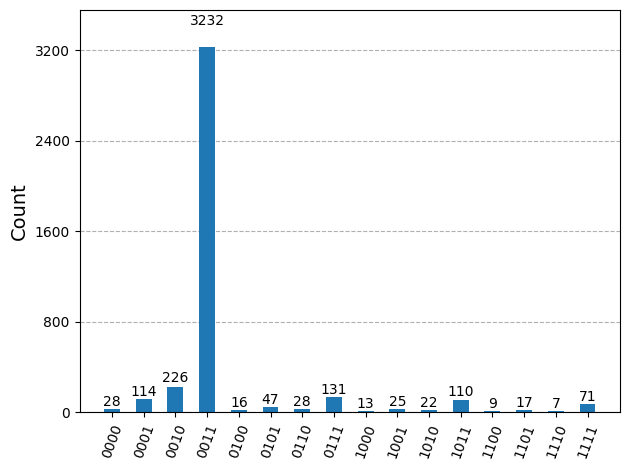

In [57]:

plot_histogram(counts)